# RQ2: Which factors most influence bike-sharing demand?

In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

import xgboost as xgb

# Load dataset
df = pd.read_csv(r'C:\Users\Admin\Downloads\SeoulBikeData.csv', encoding='latin1')

# Basic preprocessing
df.columns = df.columns.str.strip()

df['Date'] = pd.to_datetime(df['Date'], format='%d/%m/%Y')

df['Month'] = df['Date'].dt.month
df['Day'] = df['Date'].dt.day
df['Weekday'] = df['Date'].dt.weekday

encoder = LabelEncoder()

categorical_cols = ['Seasons', 'Holiday', 'Functioning Day']

for col in categorical_cols:
    df[col] = encoder.fit_transform(df[col])

X = df.drop(['Date', 'Rented Bike Count'], axis=1)
y = df['Rented Bike Count']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42
)


In [2]:

# Train Random Forest model

rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

importance = rf_model.feature_importances_

importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importance
})

importance_df = importance_df.sort_values(
    by='Importance',
    ascending=False
)

importance_df.to_csv('table2_feature_importance.csv', index=False)

print(importance_df)


                      Feature  Importance
1             Temperature(°C)    0.298192
0                        Hour    0.286876
11            Functioning Day    0.088842
6     Solar Radiation (MJ/m2)    0.088065
2                 Humidity(%)    0.059955
7                Rainfall(mm)    0.042002
14                    Weekday    0.035011
9                     Seasons    0.028911
5   Dew point temperature(°C)    0.023819
12                      Month    0.015530
13                        Day    0.009635
4            Visibility (10m)    0.008876
3            Wind speed (m/s)    0.008681
10                    Holiday    0.005046
8               Snowfall (cm)    0.000559


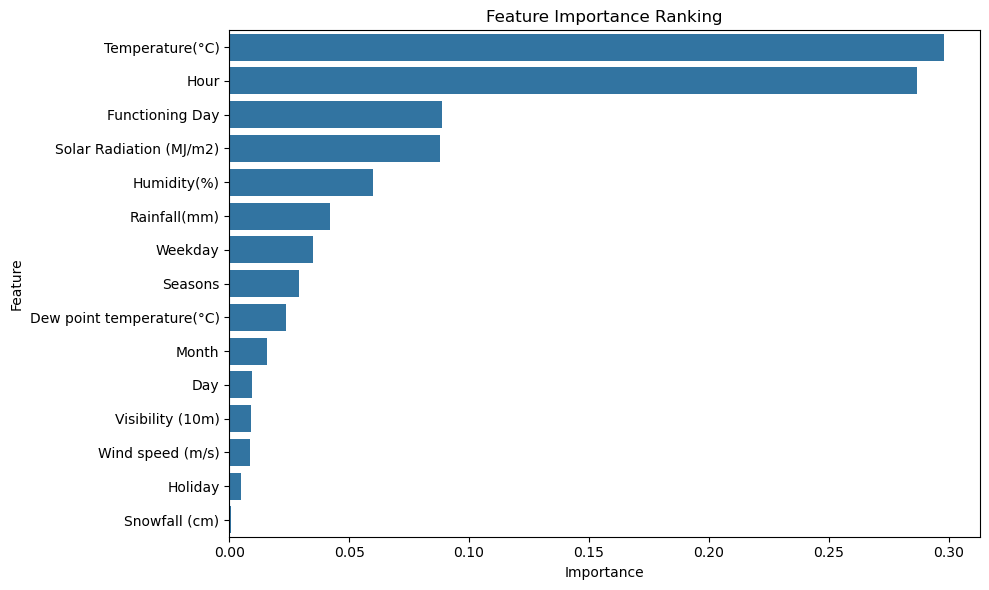

In [3]:

# Generate feature importance figure

plt.figure(figsize=(10,6))

sns.barplot(
    x='Importance',
    y='Feature',
    data=importance_df
)

plt.title('Feature Importance Ranking')

plt.tight_layout()

plt.savefig(
    'figure2_feature_importance.pdf',
    bbox_inches='tight'
)

plt.savefig(
    'figure2_feature_importance.png',
    dpi=300,
    bbox_inches='tight'
)
plt.show()
